# Question B3. Measuring Campaign ROI

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [2]:
banking_marketing_train_encoded = pd.read_csv('../data/processed/banking_marketing_train_processed.csv', delimiter=';', quotechar='"', encoding='utf-8')
banking_marketing_test_encoded = pd.read_csv('../data/processed/banking_marketing_test_processed.csv', delimiter=';', quotechar='"', encoding='utf-8')

# Models

(Polynomial regression was not chosen due to its tendency to overfit in high-dimensional spaces(there are 40+ columns) and its limited ability to capture complex non-linear interactions compared to models like Random Forest.)

In [3]:
# Define feature columns used for training the ROI prediction model
features = ['age', 'education', 'default', 'balance', 'housing', 'loan', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_unknown', 'poutcome_success',
       'poutcome_unknown', 'y', 'conversion_rate', 'interest_rate']

# Extract features (X) and target variable (y = ROI)
X = banking_marketing_train_encoded[features]
y = banking_marketing_train_encoded["ROI"]

## 1. Linear Regression with log(ROI)

In [4]:
train = banking_marketing_train_encoded.copy()
test = banking_marketing_test_encoded.copy()

# Filter out invalid ROI values (must be >= -1)
train = train[train["ROI"] >= -1].copy()
test = test[test["ROI"] >= -1].copy()

# ROI range from -1 to 1.195728e+09 
# Apply log1p to smooth extreme ROI values (highly skewed), reduce large outlier impact
train["ROI_log"] = np.log1p(train["ROI"])
test["ROI_log"] = np.log1p(test["ROI"])

# Remove rows with non-finite log(ROI) values (e.g., NaN or ±inf)
train = train[np.isfinite(train["ROI_log"])].copy()
test = test[np.isfinite(test["ROI_log"])].copy()

# Prepare training and test data (fill missing values with 0)
X_train = train[features].fillna(0)
y_train = train["ROI_log"]
X_test = test[features].fillna(0)
y_test = test["ROI_log"]

# Train a linear regression model using log-transformed ROI
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and inverse the log transform to recover original ROI scale
y_pred_log = lr.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Evaluate model performance on original ROI scale
print("Linear Regression with log(ROI):")
print("MSE:", mean_squared_error(y_true, y_pred))
print("R² Score:", r2_score(y_true, y_pred))



Linear Regression with log(ROI):
MSE: 865966039762732.5
R² Score: 0.3220818340974513


### Analysis of the training result from the baseline Linear Regression Model
The initial linear regression model using log-transformed ROI achieved an MSE of approximately 8.66e+14 and an R² score of 0.3221. This suggests that the model explains only about 32.2% of the variance in the ROI, but there is still substantial room for improvement This is likely due to the highly skewed ROI distribution, where most values are small or negative, and a few are extremely large. A log1p transformation was applied to reduce skewness and better align with the assumptions of linear regression, but it was not sufficient

To improve performance, we further applied Ridge Regression with standardization and performed hyperparameter tuning using GridSearchCV over different regularization strengths (alpha). This approach helps to reduce overfitting and improve generalization on unseen data.

Model performance will continue to be evaluated using MSE, and R², and more advanced models such as Random Forest will be explored to capture non-linear patterns in ROI prediction.

(Ridge regression was preferred over Lasso because the objective was to enhance predictive accuracy rather than perform feature selection. Ridge tends to perform better in scenarios with multicollinearity and when all features are potentially informative.)

In [5]:
# Define a pipeline: Standardize + Ridge Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define parameter grid: alpha is the regularization strength
param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100, 200]
}

# Set up grid search with 5-fold cross-validation
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

# Evaluate the best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best alpha:", grid.best_params_['ridge__alpha'])
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))



Best alpha: 0.01
Test MSE: 0.19693699349594454
Test R²: 0.9936464859504608


### Summary & Analysis of the result from the Ridge Regression Model
After applying a Ridge regression model with a standardized feature pipeline, we used 5-fold cross-validation to search for the best regularization strength (alpha). The optimal model was found with alpha = 0.01, indicating minimal regularization was sufficient for stable and accurate predictions. 

The model demonstrates excellent performance, achieving a very low Test MSE of 0.1969 and a high Test R² of 0.9936.

Compared to the baseline linear regression, the tuned Ridge model shows a significant improvement in both MSE(8.66e+14 to 0.1969) and R²(0.3221 to 0.9936), indicating better fit and lower prediction error across a wide range of ROI values. The use of regularization helps reduce overfitting, especially in the presence of multicollinearity among features.

The high R² score suggests that the model is able to explain 99.4% of the variance in ROI, making it a strong candidate for predicting campaign effectiveness. 

Overall, we are confident that this model is much more robust and better suited for our ROI prediction task than the initial baseline.

## 2. Random Forest with log(ROI)

In [6]:

# Data preparation (consistent with previous steps)
train = banking_marketing_train_encoded.copy()
test = banking_marketing_test_encoded.copy()

# Keep only valid ROI values (log1p requires ROI ≥ -1)
train = train[train["ROI"] >= -1].copy()
test = test[test["ROI"] >= -1].copy()

# Apply log1p transformation to smooth extreme ROI values
train["ROI_log"] = np.log1p(train["ROI"])
test["ROI_log"] = np.log1p(test["ROI"])

# Prepare training and test data (fill missing values with 0)
X_train = train[features].fillna(0)
y_train = train["ROI_log"]
X_test = test[features].fillna(0)
y_test = test["ROI_log"]

# Train a Random Forest Regressor on log-transformed ROI
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and inverse the log transform to recover original ROI
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)

# True ROI values
y_true = np.expm1(y_test)

# Evaluation metrics
print("Random Forest Regression with log(ROI):")
print("MSE:", mean_squared_error(y_true, y_pred))
print("R² Score:", r2_score(y_true, y_pred))


Random Forest Regression with log(ROI):
MSE: 675123832250837.8
R² Score: 0.4714819183417538


### Analysis of the training result from the baseline Random Forest Model
The initial Random Forest model trained on log-transformed ROI achieved a relatively high test MSE of 6.75e+14 and an R² score of 0.4715, indicating that the model struggles to fully capture the variation in ROI despite its non-linear structure.

Similarly, this may also be due to the extremely skewed ROI distribution. Although we applied a log transformation to smooth these extremes, the model still shows limited generalization capability.

To improve performance, we will adopt a similar approach as in earlier models—tuning hyperparameters via cross-validation—to better control overfitting and improve generalization on unseen data.

In [7]:
# Build a pipeline (Random Forest does not require standardization, but included for consistency)
pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

# Define the hyperparameter grid
param_grid = {
    'rf__n_estimators': [50, 100, 200, 300],             # Number of trees in the forest
    'rf__max_depth': [None, 5, 10, 20, 50],            # Maximum depth of the tree
    'rf__min_samples_split': [2, 5, 10],        # Minimum number of samples required to split an internal node
    'rf__max_features': ['sqrt']                # Number of features to consider when looking for the best split
}

# Perform grid search with cross-validation
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Train the model using grid search
grid.fit(X_train, y_train)

# Evaluate the best model
best_rf_model = grid.best_estimator_
y_pred = best_rf_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
MSE: 0.7812657154890941
R² Score: 0.9747950722123444


### Summary of the Random Forest Model
After performing a comprehensive grid search over key hyperparameters, the optimized Random Forest model achieved a notable improvement in performance, with an R² score increased from 0.4715 to 0.9748 and MSE reduced from 6.75e+14 to 0.7813 on the log-transformed ROI scale. This indicates the model captures the variance in ROI far more effectively compared to the baseline version.

The improvement suggests that tuning parameters such as the number of trees (n_estimators) and the depth of trees (max_depth) helped strike a better balance between bias and variance, allowing the model to generalize well without overfitting.

While the model does not provide interpretability as directly as linear models, the performance gains make it a strong candidate for predicting ROI in complex, non-linear datasets where extreme values and interactions among features are common.

# Visualization of Models

## 1. Random Forest Feature Importance Visualization

/var/folders/y3/9hj7ltxx2118c1hm9mlp2sbm0000gn/T/ipykernel_18748/1655602975.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="Blues_d")


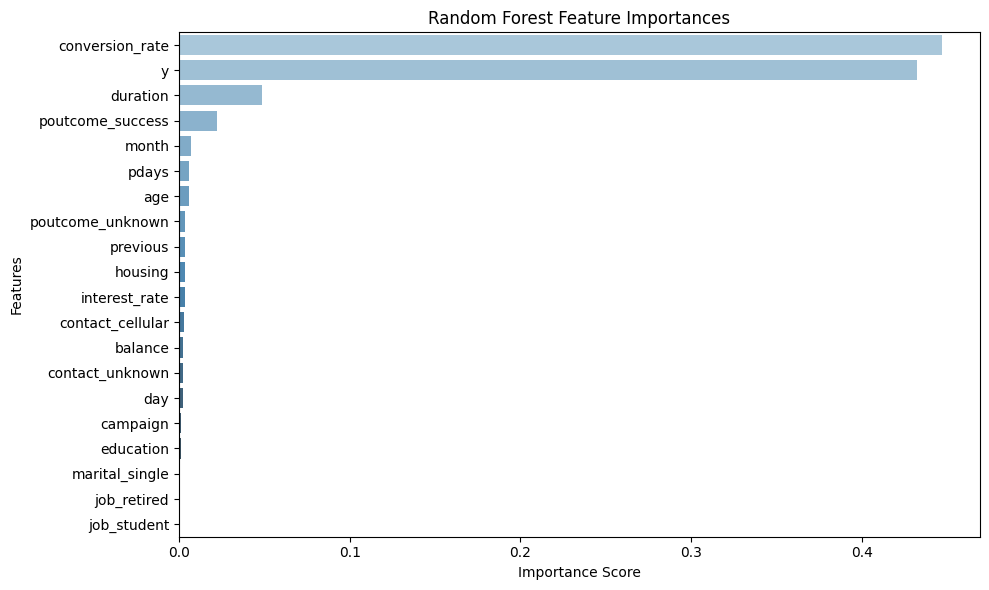

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to plot the top N most important features from a Random Forest model
def plot_RF_importance(model, feature_names, top_n=20):
    # Extract feature importance scores from the model
    importances = model.feature_importances_
    
    # Sort features by importance in descending order and select top N
    indices = np.argsort(importances)[::-1][:top_n]  

    # Create a barplot of the top N important features
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="Blues_d")
    plt.title("Random Forest Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# Plot feature importances from the best Random Forest model (extracted from the pipeline)
plot_RF_importance(best_rf_model.named_steps["rf"], X_train.columns)


## 2. Ridge Regression Coefficients Visualization

/var/folders/y3/9hj7ltxx2118c1hm9mlp2sbm0000gn/T/ipykernel_18748/879890768.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs[indices], y=np.array(feature_names)[indices], palette="coolwarm")


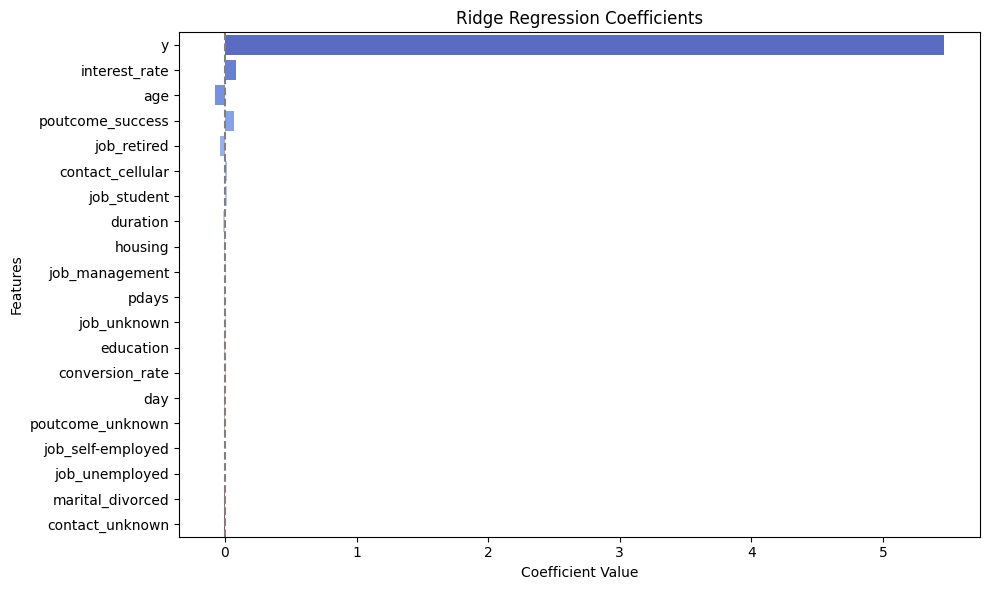

In [9]:
# Function to plot the top N coefficients from a Ridge Regression model
def plot_ridge_coefficients(model, feature_names, top_n=20):
    # Extract the coefficients from the fitted Ridge model inside the pipeline
    coefs = model.named_steps['ridge'].coef_
    
    # Get the indices of the top N coefficients by absolute magnitude
    indices = np.argsort(np.abs(coefs))[::-1][:top_n]

    # Create a bar plot showing the top N coefficients
    plt.figure(figsize=(10, 6))
    sns.barplot(x=coefs[indices], y=np.array(feature_names)[indices], palette="coolwarm")
    plt.axvline(x=0, color='gray', linestyle='--')  # Add a vertical line at 0 for reference
    plt.title("Ridge Regression Coefficients")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# Plot the most influential features from the best Ridge model
plot_ridge_coefficients(best_model, X_train.columns)


### Summary of Model Visualizations & Insights
Random Forest:  
The top predictors of ROI are:  
conversion_rate – by far the most influential, showing that a customer's prior engagement level is a powerful signal of future ROI.  
y (subscription outcome) – reflects direct success of the campaign.  
duration – longer interactions may indicate stronger customer interest or sales effectiveness.  
poutcome_success and month follow, with minor contributions from pdays and age.

Ridge Regression:  
y as the most significant positive contributor, reinforcing the importance of actual subscription.  
interest_rate, age, and poutcome_success also have moderate impact.  
Notably, conversion_rate has limited effect in Ridge, indicating multicollinearity or model-specific dynamics.


### Insights & Recommendation
Key Insight & Business Implication:  
The models consistently indicate that:  
Campaign success (y, poutcome_success) and financial value (interest_rate) are drivers of ROI.  
Conversion_rate, though dominant in Random Forest, is less so in Ridge – suggesting it may interact with other variables or be more impactful in non-linear models.

Business Recommendation:  
Prioritize outreach to users with high conversion history and successful past outcomes.  
Adjust messaging or offers based on interest_rate attractiveness to influence ROI positively.  
Segment audiences by age and engagement duration to tailor strategies and improve cost-efficiency.

Additional Feature Insights:  
duration: Longer calls likely indicate more engaged customers, possibly better persuasion or interest → a proxy for call quality.  
age: Older users may represent higher-value segments (e.g., more savings, longer deposit terms), supporting demographic-based targeting.  
conversion_rate: High prior responsiveness = high ROI potential. Prioritize these customers in future campaigns.


# Final Model Chosen

The Ridge Regression model was selected as the final model due to its outstanding performance in predicting ROI. With a test R² score of 0.9936 and the lowest test MSE of 0.1969, it demonstrated strong predictive accuracy and stability. Although the Random Forest model also performed well (R² = 0.9748, MSE = 0.7813), Ridge’s simpler structure and better generalization make it more interpretable and efficient for deployment. Given its consistent results and minimal overfitting, Ridge Regression offers the best trade-off between performance and simplicity for ROI prediction.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

train = banking_marketing_train_encoded.copy()
test = banking_marketing_test_encoded.copy()

# Filter out invalid ROI values (must be >= -1)
train = train[train["ROI"] >= -1].copy()
test = test[test["ROI"] >= -1].copy()

# ROI range from -1 to 1.195728e+09 
# Apply log1p to smooth extreme ROI values (highly skewed), reduce large outlier impact
train["ROI_log"] = np.log1p(train["ROI"])
test["ROI_log"] = np.log1p(test["ROI"])

# Remove rows with non-finite log(ROI) values (e.g., NaN or ±inf)
train = train[np.isfinite(train["ROI_log"])].copy()
test = test[np.isfinite(test["ROI_log"])].copy()

# Prepare training and test data (fill missing values with 0)
X_train = train[features].fillna(0)
y_train = train["ROI_log"]
X_test = test[features].fillna(0)
y_test = test["ROI_log"]

# Train a linear regression model using log-transformed ROI
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and inverse the log transform to recover original ROI scale
y_pred_log = lr.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Define a pipeline: Standardize + Ridge Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define parameter grid: alpha is the regularization strength
param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100, 200]
}

# Set up grid search with 5-fold cross-validation
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

# Evaluate the best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best alpha:", grid.best_params_['ridge__alpha'])
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))



Best alpha: 0.01
Test MSE: 0.19693699349594454
Test R²: 0.9936464859504608
